In [32]:
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from torchgeo_bench.coordbench.datasets import load_chelsa
from torchgeo_bench.coordbench.models import ClimplicitLocationEncoder
from torchgeo_bench.coordbench.temporal_aggregation import temporal_aggregation
from torchgeo_bench.coordbench.probe import spatial_fold_ids

In [33]:
var = "tas"
b = load_chelsa()[0]
enc = ClimplicitLocationEncoder(device="cuda" if torch.cuda.is_available() else "cpu")
bb, E = temporal_aggregation(b, "4_week", enc)          # same as earlier: 4_week windows
lat, lon, y = bb.lat, bb.lon, bb.tasks[var].astype(np.float64)

Output()

In [34]:
la, lo = np.radians(lat), np.radians(lon)
X_coord = np.concatenate(
    [np.c_[np.sin(k * la), np.cos(k * la), np.sin(k * lo), np.cos(k * lo)] for k in (1, 2, 4, 8, 16)],
    axis=1,
)
feats = {"climplicit": E, "sincos": X_coord}

In [35]:
fold = spatial_fold_ids(lat, lon)                        # same spatial folds as earlier
land = lat > -60

In [36]:
def oof(X, train_mask):
    """Exact earlier ridge; train only on rows in train_mask, predict every held-out row."""
    pred = np.zeros(len(y))
    for f in range(5):
        tr, te = (fold != f) & train_mask, fold == f
        s = StandardScaler().fit(X[tr])
        m = RidgeCV(alphas=np.logspace(-3, 5, 9)).fit(s.transform(X[tr]), y[tr])
        pred[te] = m.predict(s.transform(X[te]))
    return pred

In [37]:
settings = {"train: all locations": np.ones(len(y), bool), "train: lat > -60 only": land}
band = pd.cut(lat, [-90, -60, -30, 0, 30, 60, 90])


train: all locations | climplicit
 (-90, -60]    268.0
(-60, -30]    188.0
(-30, 0]      128.0
(0, 30]       130.0
(30, 60]      147.0
(60, 90]      129.0

train: all locations | sincos
 (-90, -60]    126.0
(-60, -30]     78.0
(-30, 0]       59.0
(0, 30]        66.0
(30, 60]      124.0
(60, 90]      145.0

train: lat > -60 only | climplicit
 (-90, -60]    511.0
(-60, -30]     25.0
(-30, 0]       18.0
(0, 30]        19.0
(30, 60]       35.0
(60, 90]       45.0

train: lat > -60 only | sincos
 (-90, -60]    918.0
(-60, -30]     66.0
(-30, 0]       59.0
(0, 30]        64.0
(30, 60]      122.0
(60, 90]      141.0


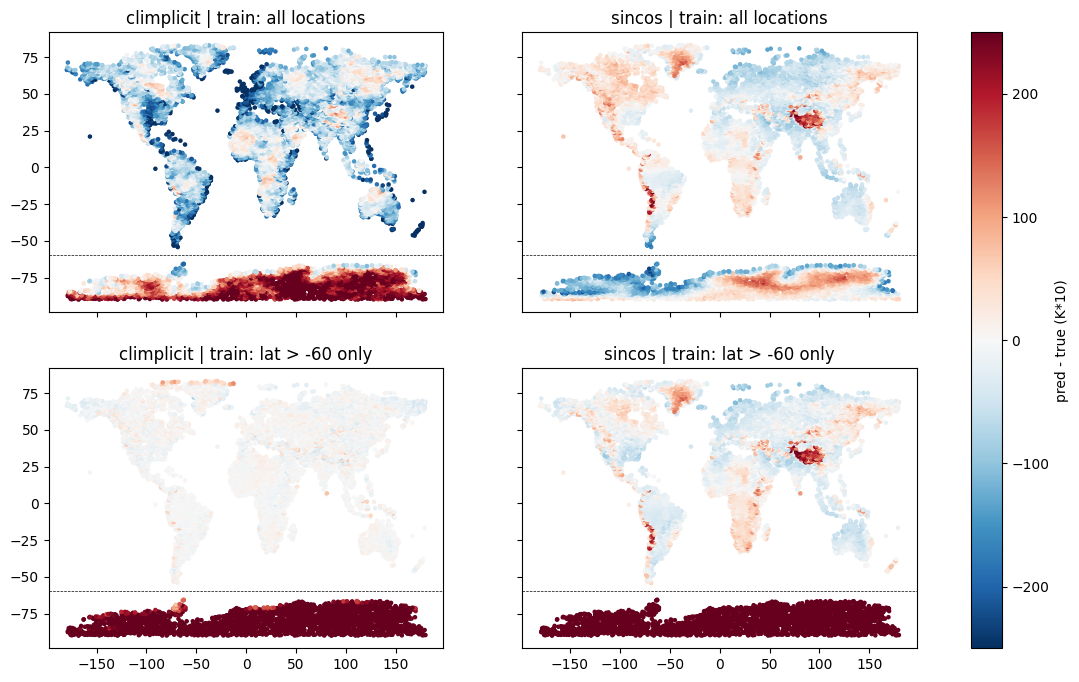

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for i, (sname, tmask) in enumerate(settings.items()):
    for j, (fname, X) in enumerate(feats.items()):
        r = oof(X, tmask) - y
        rmse = pd.Series(r**2).groupby(band, observed=True).mean() ** 0.5
        print(f"\n{sname} | {fname}\n", rmse.round(0).to_string())
        # average residual per location for plotting
        loc = pd.DataFrame({"lat": lat, "lon": lon, "r": r}).groupby(["lat", "lon"]).r.mean().reset_index()
        ax = axes[i, j]
        sc = ax.scatter(loc.lon, loc.lat, c=loc.r, s=5, cmap="RdBu_r", vmin=-250, vmax=250)
        ax.axhline(-60, color="k", lw=0.5, ls="--")
        ax.set_title(f"{fname} | {sname}")
fig.colorbar(sc, ax=axes, label="pred - true (K*10)")
plt.show()

In [39]:
ant = ~land
def within(X):
    pred = np.full(len(y), np.nan)
    for f in range(5):
        tr, te = (fold != f) & ant, (fold == f) & ant
        if te.sum() == 0 or tr.sum() == 0: continue
        s = StandardScaler().fit(X[tr])
        m = RidgeCV(alphas=np.logspace(-3, 5, 9)).fit(s.transform(X[tr]), y[tr])
        pred[te] = m.predict(s.transform(X[te]))
    k = ant & np.isfinite(pred)
    return 1 - ((y[k] - pred[k])**2).sum() / ((y[k] - y[k].mean())**2).sum()

for n, X in feats.items():
    print(n, "within-Antarctica spatial-CV R2:", round(within(X), 3))


climplicit within-Antarctica spatial-CV R2: 0.127
sincos within-Antarctica spatial-CV R2: 0.374


# Plot similarity map for embeddings in Antarctica

In [42]:
from torchgeo_bench.coordbench.models import ClimplicitLocationEncoder, TemporalSatCLIPEncoder

In [48]:
dev = "cuda" if torch.cuda.is_available() else "cpu"
q_lat, q_lon = -80.0, 60.0                                   # query point in Antarctica
dates = [pd.Timestamp(2017, 1, 15, tz="UTC"), pd.Timestamp(2017, 7, 15, tz="UTC")]                   # one day, used by both models
step = 1.0  

In [49]:
encoders = {
    "Climplicit": ClimplicitLocationEncoder(device=dev),
    "T-SatCLIP (doy)": TemporalSatCLIPEncoder(
        ckpt_path="/home/libe2152/projects/temporal-satclip/ckpts/tsatclip-doy-1M.ckpt",
        repo_path="/home/libe2152/projects/temporal-satclip",
        model_name="tsatclip/doy",
        device=dev,
    ),
}

using pretrained moco vit16
using loss function: satclip_loss
using temporal model: True


In [50]:
lats = np.arange(-90 + step / 2, 90, step)
lons = np.arange(-180 + step / 2, 180, step)
LON, LAT = np.meshgrid(lons, lats)
glon, glat = LON.ravel(), LAT.ravel()

In [51]:
def embed(enc, lon, lat, date):
    return enc.encode(np.asarray(lon, float), np.asarray(lat, float),
                      np.full(len(lon), date.timestamp()))

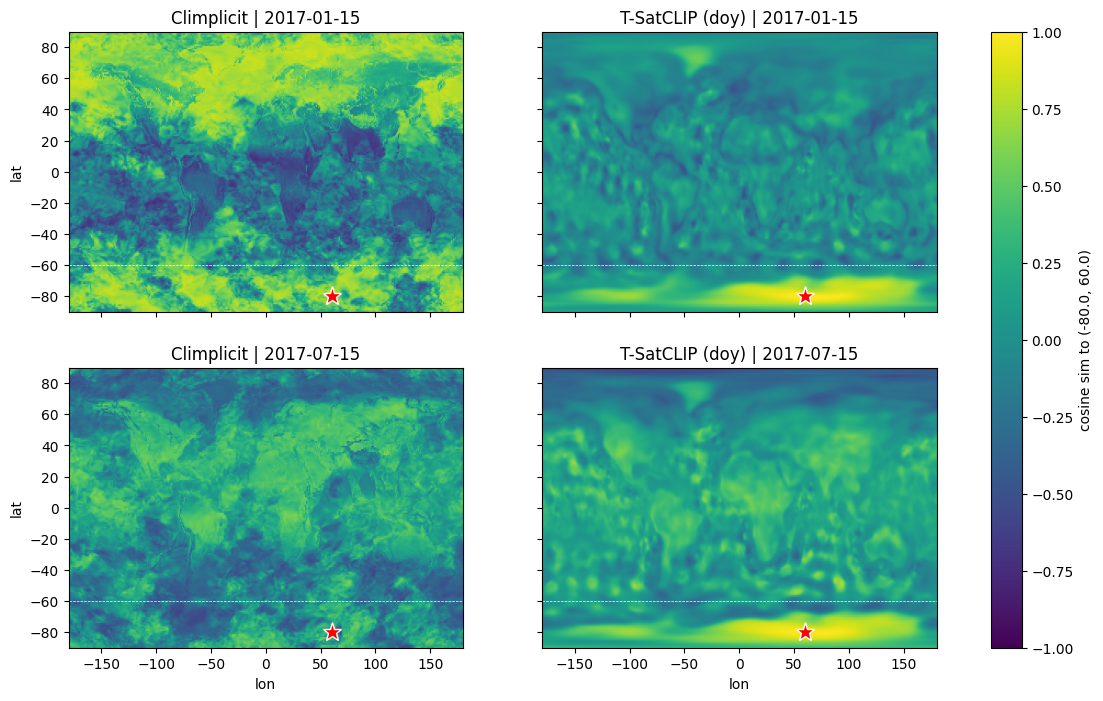

In [56]:
fig, axes = plt.subplots(len(dates), len(encoders), figsize=(7 * len(encoders), 4 * len(dates)),
                         sharex=True, sharey=True, squeeze=False)
for r, date in enumerate(dates):
    for c, (name, enc) in enumerate(encoders.items()):
        ax = axes[r, c]
        G = embed(enc, glon, glat, date)
        q = embed(enc, [q_lon], [q_lat], date)[0]
        G = G / (np.linalg.norm(G, axis=1, keepdims=True) + 1e-12)
        q = q / (np.linalg.norm(q) + 1e-12)
        sim = (G @ q).reshape(LAT.shape)
        im = ax.imshow(sim, origin="lower", extent=[-180, 180, -90, 90], cmap="viridis",
                       vmin=-1, vmax=1, aspect="auto")
        ax.plot(q_lon, q_lat, marker="*", ms=14, color="red", mec="white")
        ax.axhline(-60, color="w", lw=0.5, ls="--")
        ax.set_title(f"{name} | {date.date()}")
        if r == len(dates) - 1:
            ax.set_xlabel("lon")
        if c == 0:
            ax.set_ylabel("lat")
fig.colorbar(im, ax=axes, label=f"cosine sim to ({q_lat}, {q_lon})")
plt.show()